In [1]:
import numpy as np
import pandas as pd
import json
import os
import glob
from typing import Dict, List
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import math

In [ ]:
# Cell 1: Import and setup
import sys
import os
sys.path.append('retry')

from main_simulation_simple import GeneralSimulationRunner

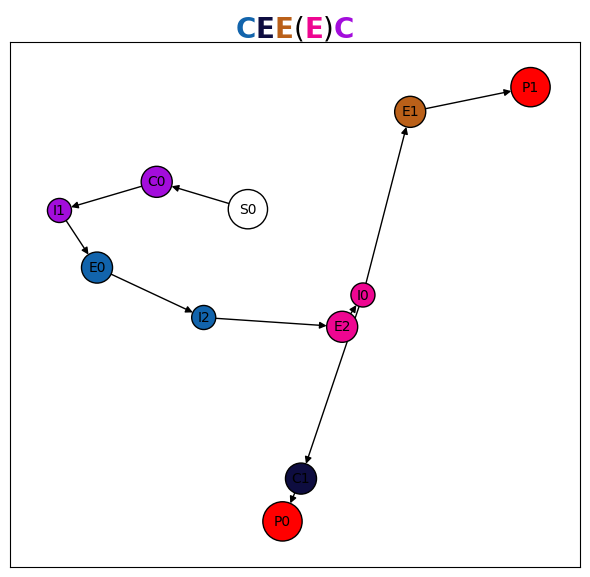

In [3]:
from simulation_utils import *
my_graph = generate_good_ce_digraph(num_nodes = 5, ce_ratio = 0.4, sparsity = 0.01, num_final_steps=2, random_state = 2)
my_graph_fleshed = insert_intermediates(my_graph)
unparser = SynthesisUnparser(my_graph)
text = unparser.to_string_with_markers()
draw_special(my_graph_fleshed, text)
print()

In [4]:
from simulation_utils import *
import random
from typing import Set

def _generate_single_mechanism(seed = 1):
    random.seed(seed)

    # Choose number of final steps first
    num_final_steps = random.choice([1, 1, 1, 2, 2, 2, 3])

    # Ensure num_nodes is at least twice the number of final steps
    min_nodes = 2 * num_final_steps
    possible_nodes = [n for n in range(min_nodes, 11)]
    num_nodes = random.choice(possible_nodes)

    ce_ratio = random.uniform(0.3, 0.6)

    graph = generate_good_ce_digraph(
        num_nodes=num_nodes,
        ce_ratio=ce_ratio,
        sparsity=0.01,
        num_final_steps=num_final_steps,
        random_state=seed,
    )

    unparser = SynthesisUnparser(graph)
    return unparser.to_string_with_markers()


def get_mechanisms(num_strings = 1, seed = 1):

    rng = random.Random(seed)
    mechanisms: Set[str] = set()

    while len(mechanisms) < num_strings:
        sub_seed = rng.randint(0, 2**32 - 1)
        mechanisms.add(_generate_single_mechanism(sub_seed))

    return mechanisms


In [5]:
print(list(get_mechanisms(10, 2)))

['CE', '(Ca1)E(Ca1E)CEE', '(E1)CE1EC1C', '(E3)(C2)(EE2)(E1)CC1E2C3', '(C5)(E3)(C2)EC1C2C3E1E5E', '(E(C4)4)(C3)CECE3C4C5', '(E(E)1)CE1', 'E(C)CEE', 'ECC(C)EE', '(Ca5)(E(C33)3)(C(C)3)E3E3EC(Ca5)3C']


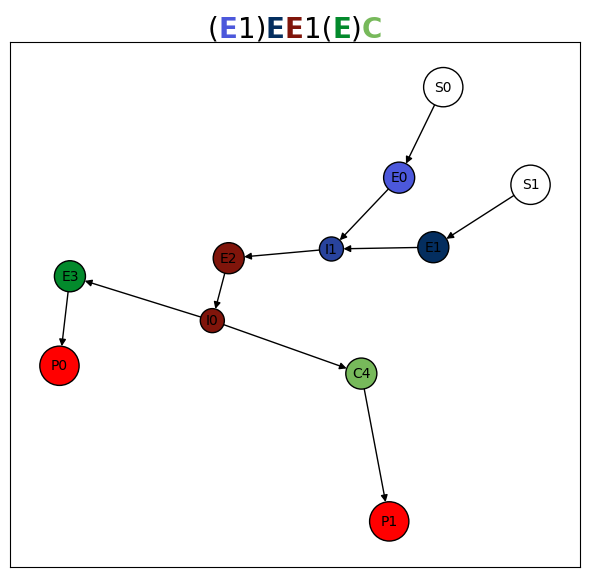

In [6]:
text = "(E1)EE1(E)C"
parser = SynthesisParser(text)
new_graph = parser.parse()  # do not overwrite original grap
new_graph_fleshed = insert_intermediates(new_graph)
draw_special(new_graph_fleshed, text)

In [7]:
text = "EC"
parser = SynthesisParser(text)
new_graph = parser.parse()  # do not overwrite original grap
G_with_intermediates = insert_intermediates(new_graph)

param_map = {
  "E0": {
    "type": "E",
    "params": [
      1,
      "oxidation",
      -0.6606283552286656,
      0.0002585607068571296,
      0.583403414766502
    ]
  },
  "C1": {
    "type": "C",
    "params": [
      1045.465719992965,
      0.0005773633594361184
    ]
  },
  "S0": {
    "type": "S",
    "params": 1
  },
  "I0": {
    "type": "I",
    "params": 0
  },
  "P0": {
    "type": "P",
    "params": 0
  }
}

model = None

comsol_params = {
    'startPotential': -1.0,
    'numCycles': 1,
    'vertexPotential1': 1.0,
    'vertexPotential2': -1.0,
    'endPotential': -1.0,
    'electrodeRadius': 1.0,  # mm
    'startScanRate': 0.0001,  # V/s
    'endScanRate': 100000.0,  # V/s  
    'scanRateCount': 5,
    'normalizeCurrent': True,
}

scan_rates = [0.01]

run_digisim_simulation(G_with_intermediates, param_map, model, comsol_params=comsol_params, scan_rates=scan_rates)

DigiSim scan rates: [0.01]
['I0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}S0', 'I0{SPACE}={SPACE}P0']
DigiSim simulation error: (-2147220991, 'An event was unable to invoke any of the subscribers', (None, None, None, 0, None))


Traceback (most recent call last):
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 2725, in run_digisim_simulation
    view_button.child_window(title="View", control_type="Window").child_window(title="View", control_type="Menu").child_window(title="Preferences...", auto_id="32409", control_type="MenuItem").click_input()
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\application.py", line 379, in __getattribute__
    ctrls = self.__resolve_control(self.criteria)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\application.py", line 250, in __resolve_control
    ctrl = wait_until_passes(
           ^^^^^^^^^^^^^^^^^^
  File "c:

{'error': "(-2147220991, 'An event was unable to invoke any of the subscribers', (None, None, None, 0, None))",
 'scan_rates': [0.01]}

In [ ]:
mechanisms = ["EEE", "ECE"]
for mechanism in mechanisms:
    # Instantiate the mechanism
    runner = GeneralSimulationRunner(
        mechanism=mechanism,
        num_simulations=250,
        random_state=1,
        total_cores=16
    )


    # Generate the parameter maps for that mechanism
    runner.generate_all_param_maps()

    # Run all the simulations
    runner.run_all_simulations_parallel()
